## Equilibrium composition of ceria vs. temperature and pressure
This Jupyter notebook walks through the calculation of the equilibrium
composition of CeO<sub>2-x</sub> as a function of temperature and pressure using
the kinetic model in the following paper:
https://doi.org/10.1021/jp406578z

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#### Step 2: Define kinetic parameters from paper

In [2]:
x = 0.35  # max off-stoichiometry
n = 0.218  # ± 0.0013, gas power law ≈ x / 2
Ev = 195.6  # ± 1.2 kJ/mol, oxygen vacancy formation energy
kred0_kox0 = 8700  # ± 800 bar^n, k_{red,0}/k_{ox,0}

Here, $x$ is the maximum off-stoichiometry ($\delta$), $n$ is the gas-power law
($\approx x / 2$), $E_v$ is the oxygen vacancy formation energy in kJ/mol, and
$k_{red,0}/k_{ox,0}$ is the ratio of the Arrhenius prefactors for the following
chemical reaction:

CeO<sub>2</sub>(s) $\rightleftharpoons$ CeO<sub>2-$\delta$</sub>(s) +
$\frac{1}{2}$ O<sub>2</sub>(g)

#### Step 3: Define experimental conditions

In [3]:
R = 0.008314462618  # kJ/(mol K)
T = np.linspace(1300, 2300, 101)
RT = R * T
P = 1E-3  # bar

#### Step 4: Calculate and visualize equilibrium composition vs. T

$\delta=\frac{x}{\frac{k_{ox,0}}{k_{red,0}} P_{O_2}^n e^{\frac{E_v}{RT}} + 1}$

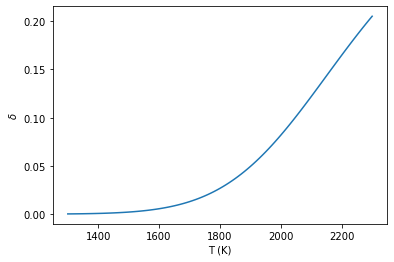

In [4]:
delta = x / ((kred0_kox0 * P ** (-n) * np.exp(-Ev / RT)) ** (-1) + 1)
plt.plot(T, delta)
plt.xlabel("T (K)")
plt.ylabel(r"$\delta$")
plt.show()